# Location-Based Seasonal Crop Prediction for Shimla
### ANN for Rainfall Prediction + Fuzzy Logic for Season and Crop Recommendation
Region: Shimla, Himachal Pradesh | Data: NASA POWER (2000-2024) + Crop Recommendation Dataset

## 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2

print('All libraries imported.')

All libraries imported.


## 2. Load Shimla Rainfall Data (NASA POWER Dataset)

In [ ]:
import pandas as pd
import numpy as np
from google.colab import files

uploaded = files.upload()
file_name = list(uploaded.keys())[0]

rain_df = pd.read_csv(file_name, skiprows=15, engine='python')
rain_df.columns = rain_df.columns.str.strip()

# The CSV contains 7 weather parameters. Filter only rainfall.
rain_df = rain_df[rain_df['PARAMETER'] == 'PRECTOTCORR_SUM'].copy()
rain_df = rain_df.drop(columns=['PARAMETER', 'ANN', 'YEAR'], errors='ignore')

month_cols = ['JAN','FEB','MAR','APR','MAY','JUN',
              'JUL','AUG','SEP','OCT','NOV','DEC']
rain_values = rain_df[month_cols].values.flatten().astype(float)
rain_values = rain_values[rain_values != -999]

print('Region  : Shimla, Himachal Pradesh (31.12 N, 77.13 E)')
print('Period  : 2000 to 2024 (NASA POWER / MERRA-2)')
print('Total monthly data points :', len(rain_values))
print('Mean monthly rainfall      :', round(rain_values.mean(), 2), 'mm')
print('Min / Max                  :', round(rain_values.min(), 2), '/', round(rain_values.max(), 2), 'mm')

Saving POWER_Point_Monthly_20000101_20241231_031d12N_077d13E_LST.csv to POWER_Point_Monthly_20000101_20241231_031d12N_077d13E_LST.csv
Region  : Shimla, Himachal Pradesh (31.12 N, 77.13 E)
Period  : 2000 to 2024 (NASA POWER / MERRA-2)
Total monthly data points : 300
Mean monthly rainfall      : 94.26 mm
Min / Max                  : 0.0 / 535.39 mm


### Rainfall Time-Series Overview

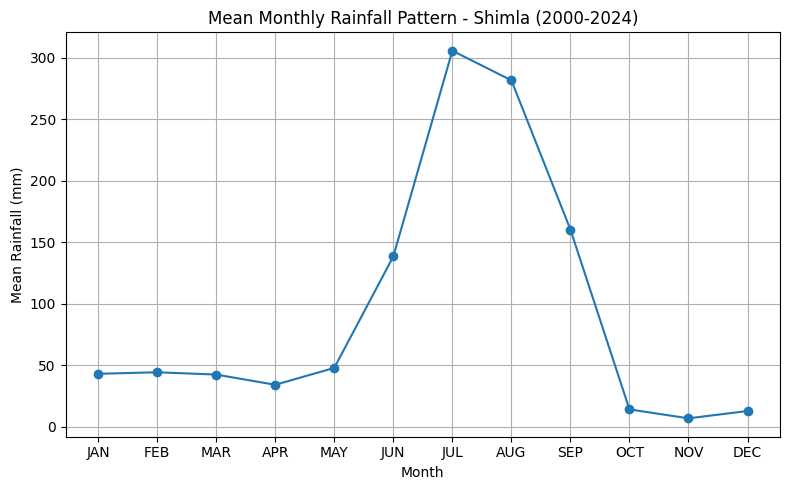

In [ ]:
rain_df_plot = pd.read_csv(file_name, skiprows=15, engine='python')
rain_df_plot.columns = rain_df_plot.columns.str.strip()
rain_df_plot = rain_df_plot[rain_df_plot['PARAMETER'] == 'PRECTOTCORR_SUM'].copy()

month_cols = ['JAN','FEB','MAR','APR','MAY','JUN',
              'JUL','AUG','SEP','OCT','NOV','DEC']
month_means = rain_df_plot[month_cols].mean()
months = np.arange(1, 13)

plt.figure(figsize=(8, 5))
plt.plot(months, month_means.values, marker='o')
plt.xticks(months, month_cols)
plt.xlabel('Month')
plt.ylabel('Mean Rainfall (mm)')
plt.title('Mean Monthly Rainfall Pattern - Shimla (2000-2024)')
plt.grid()
plt.tight_layout()
plt.show()

## 3. Prepare Rainfall Dataset (Sliding Window)

In [ ]:
WINDOW = 12  # past 12 months used to predict the next month

def create_sequences(data, window=12, horizon=1):
    """
    Converts time-series into supervised learning format.
    Input  (X): window months of past rainfall
    Output (y): the next month's rainfall (horizon steps ahead)
    """
    X, y = [], []
    for i in range(len(data) - window - horizon + 1):
        X.append(data[i : i + window])
        y.append(data[i + window : i + window + horizon])
    return np.array(X), np.array(y)

X_rain_raw, y_rain_raw = create_sequences(rain_values, WINDOW, horizon=1)
y_rain_raw = y_rain_raw.squeeze()

print('X shape:', X_rain_raw.shape)
print('y shape:', y_rain_raw.shape)

X shape: (288, 12)
y shape: (288,)


## 4. Scale Features
A single MinMaxScaler is fitted only on the training data and applied consistently
to both X and y. This avoids data leakage.

In [ ]:
X_rain_tr, X_rain_te, y_rain_tr, y_rain_te = train_test_split(
    X_rain_raw, y_rain_raw, test_size=0.15, shuffle=False
)

scaler_rain = MinMaxScaler(feature_range=(0, 1))
scaler_rain.fit(X_rain_tr.reshape(-1, 1))

X_rain_tr_s = scaler_rain.transform(X_rain_tr.reshape(-1, 1)).reshape(X_rain_tr.shape)
X_rain_te_s = scaler_rain.transform(X_rain_te.reshape(-1, 1)).reshape(X_rain_te.shape)
y_rain_tr_s = scaler_rain.transform(y_rain_tr.reshape(-1, 1))
y_rain_te_s = scaler_rain.transform(y_rain_te.reshape(-1, 1))

print('Training samples :', X_rain_tr_s.shape[0])
print('Test samples     :', X_rain_te_s.shape[0])

Training samples : 244
Test samples     : 44


## 5. Stage 1 - ANN: Rainfall Prediction

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    min_delta=0.0001
)

model_rain = Sequential([
    Input(shape=(WINDOW,)),
    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.3),
    Dense(32, activation='relu', kernel_regularizer=l2(0.001)),
    Dense(1)
])

model_rain.compile(
    optimizer='adam',
    loss='huber',
    metrics=['mae']
)
model_rain.summary()

history_rain = model_rain.fit(
    X_rain_tr_s, y_rain_tr_s,
    validation_split=0.15,
    epochs=300,
    batch_size=8,
    callbacks=[early_stop],
    verbose=1
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,945 (11.50 KB)

 Trainable params: 2,945 (11.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/300
26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - loss: 0.0980 - mae: 0.2000 - val_loss: 0.0773 - val_mae: 0.1746
Epoch 2/300
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0703 - mae: 0.1432 - val_loss: 0.0627 - val_mae: 0.1290
Epoch 3/300
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0628 - mae: 0.1326 - val_loss: 0.0550 - val_mae: 0.1160
Epoch 4/300
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0562 - mae: 0.1187 - val_loss: 0.0491 - val_mae: 0.1081
Epoch 5/300
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0522 - mae: 0.1237 - val_loss: 0.0439 - val_mae: 0.0986
Epoch 6/300
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0466 - mae: 0.1052 - val_loss: 0.0405 - val_mae: 0.0969
Epoch 7/300
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0441 - mae: 0.1111 - val_loss: 0.0382 - val_mae: 0.1011
Epoch 8/300
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0415 - mae: 0.1126 - val_loss: 0.0352 - val_mae: 0.0978
Epoch 9/300
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.03

### Rainfall Model Evaluation

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 361ms/step
Rainfall ANN - Test Set Metrics
  MSE  : 7667.4428
  RMSE : 87.5639
  MAE  : 58.6837


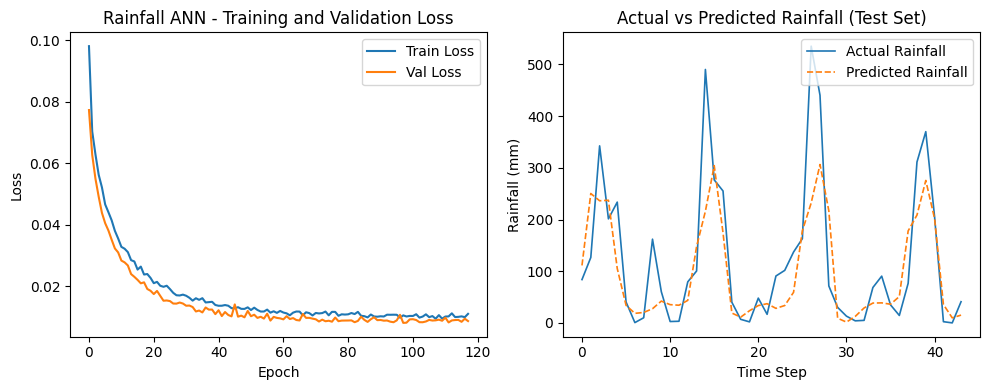

In [ ]:
y_pred_s = model_rain.predict(X_rain_te_s)

y_pred   = scaler_rain.inverse_transform(y_pred_s)
y_actual = scaler_rain.inverse_transform(y_rain_te_s)

mse  = mean_squared_error(y_actual, y_pred)
mae  = mean_absolute_error(y_actual, y_pred)
rmse = np.sqrt(mse)

print('Rainfall ANN - Test Set Metrics')
print('  MSE  :', round(mse, 4))
print('  RMSE :', round(rmse, 4))
print('  MAE  :', round(mae, 4))

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history_rain.history['loss'], label='Train Loss')
plt.plot(history_rain.history['val_loss'], label='Val Loss')
plt.title('Rainfall ANN - Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(y_actual[:80], label='Actual Rainfall', linewidth=1.2)
plt.plot(y_pred[:80],   label='Predicted Rainfall', linewidth=1.2, linestyle='--')
plt.title('Actual vs Predicted Rainfall (Test Set)')
plt.xlabel('Time Step')
plt.ylabel('Rainfall (mm)')
plt.legend()

plt.tight_layout()
plt.show()

## 6. Stage 2 - Fuzzy Logic: Season Classification
Rainfall is converted into linguistic categories using overlapping triangular
membership functions. Overlapping boundaries reflect the real-world uncertainty
in where one season ends and another begins.

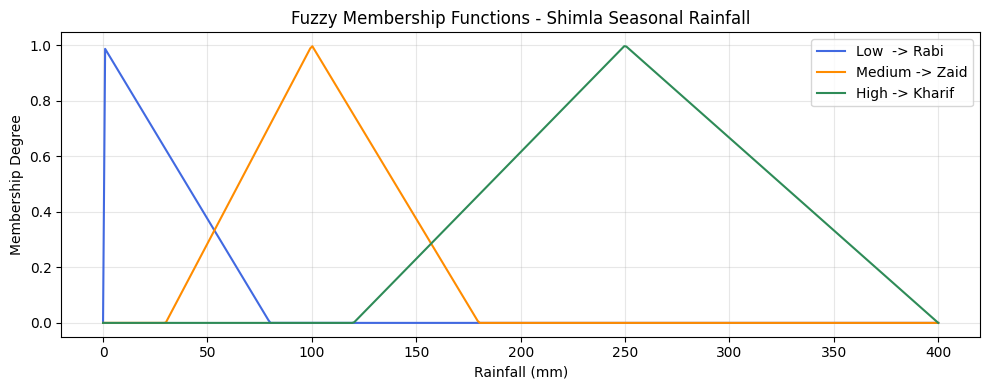

Fuzzy season module ready.


In [ ]:
def triangular_mf(x, a, b, c):
    """Triangular membership function."""
    if x <= a or x >= c:
        return 0.0
    elif x <= b:
        return (x - a) / (b - a)
    else:
        return (c - x) / (c - b)

def fuzzy_season(rainfall_mm):
    """
    Classify agricultural season from predicted rainfall.
    Shimla-specific thresholds based on Himalayan climate.
      Rabi   - winter crops  - low rainfall
      Zaid   - summer crops  - medium rainfall
      Kharif - monsoon crops - high rainfall
    """
    r = rainfall_mm
    mu_low    = triangular_mf(r,   0,   0,  80)
    mu_medium = triangular_mf(r,  30, 100, 180)
    mu_high   = triangular_mf(r, 120, 250, 400)

    memberships = {'Rabi': mu_low, 'Zaid': mu_medium, 'Kharif': mu_high}
    season = max(memberships, key=memberships.get)
    return season, memberships

rf_range  = np.linspace(0, 400, 400)
mu_low    = [triangular_mf(r,   0,   0,  80) for r in rf_range]
mu_medium = [triangular_mf(r,  30, 100, 180) for r in rf_range]
mu_high   = [triangular_mf(r, 120, 250, 400) for r in rf_range]

plt.figure(figsize=(10, 4))
plt.plot(rf_range, mu_low,    label='Low  -> Rabi',    color='royalblue')
plt.plot(rf_range, mu_medium, label='Medium -> Zaid',  color='darkorange')
plt.plot(rf_range, mu_high,   label='High -> Kharif',  color='seagreen')
plt.title('Fuzzy Membership Functions - Shimla Seasonal Rainfall')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Membership Degree')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('Fuzzy season module ready.')

## 7. Load Crop Recommendation Dataset

In [ ]:
from google.colab import files

uploaded = files.upload()
crop_file = list(uploaded.keys())[0]

crop_df = pd.read_csv(crop_file)

print('Dataset : Crop Recommendation Dataset')
print('Shape   :', crop_df.shape)
print('Crops   :', sorted(crop_df['label'].unique()))
crop_df.head()

Saving Crop_recommendation.csv to Crop_recommendation.csv
Dataset : Crop Recommendation Dataset
Shape   : (2200, 8)
Crops   : ['apple', 'banana', 'blackgram', 'chickpea', 'coconut', 'coffee', 'cotton', 'grapes', 'jute', 'kidneybeans', 'lentil', 'maize', 'mango', 'mothbeans', 'mungbean', 'muskmelon', 'orange', 'papaya', 'pigeonpeas', 'pomegranate', 'rice', 'watermelon']


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


## 8. Stage 3 - Fuzzy Crop Recommendation

In [ ]:
import numpy as np

# Membership function shapes
def trimf(x, a, b, c):
    """Triangular membership function: rises a to b, falls b to c."""
    if x <= a or x >= c:
        return 0.0
    elif x <= b:
        return (x - a) / (b - a)
    else:
        return (c - x) / (c - b)

def trapmf(x, a, b, c, d):
    """Trapezoidal membership function: rises a to b, flat b to c, falls c to d."""
    if x <= a or x >= d:
        return 0.0
    elif x <= b:
        return (x - a) / (b - a)
    elif x <= c:
        return 1.0
    else:
        return (d - x) / (d - c)

# Fuzzification functions for each input
# Thresholds are derived from per-crop mean values in the dataset

def fuzzify_N(v):
    return {
        'Low'   : trapmf(v,  0,  0, 20, 45),
        'Medium': trimf (v, 30, 65, 95),
        'High'  : trapmf(v, 80,110,140,140)
    }

def fuzzify_P(v):
    return {
        'Low'   : trapmf(v,  0,  0, 20, 45),
        'Medium': trimf (v, 30, 60, 90),
        'High'  : trapmf(v, 75,110,145,145)
    }

def fuzzify_K(v):
    return {
        'Low'   : trapmf(v,  0,  0, 20, 45),
        'Medium': trimf (v, 30, 50, 80),
        'High'  : trapmf(v, 60,100,205,205)
    }

def fuzzify_temp(v):
    return {
        'Cool'    : trapmf(v,  0,  0, 20, 24),
        'Moderate': trimf (v, 20, 25, 30),
        'Hot'     : trapmf(v, 27, 32, 45, 45)
    }

def fuzzify_humidity(v):
    return {
        'Low'   : trapmf(v,  0,  0, 25, 50),
        'Medium': trimf (v, 40, 65, 85),
        'High'  : trapmf(v, 75, 90,100,100)
    }

def fuzzify_ph(v):
    return {
        'Acidic'  : trapmf(v, 3.0, 3.0, 5.5, 6.2),
        'Neutral' : trimf (v, 5.8, 6.5, 7.2),
        'Alkaline': trapmf(v, 6.8, 7.5,10.0,10.0)
    }

def fuzzify_rain(v):
    return {
        'VeryLow': trapmf(v,   0,   0,  35,  60),
        'Low'    : trimf (v,  40,  70, 100),
        'Medium' : trimf (v,  85, 115, 155),
        'High'   : trapmf(v, 140, 190, 310, 310)
    }

def _and(*vals):
    """Fuzzy AND operator - returns the minimum membership value."""
    return min(vals)


def recommend_crop_fuzzy(N, P, K, temperature, humidity, ph, rainfall):
    """
    Fuzzy crop recommendation engine.
    Each crop has a rule defined by its typical soil and climate profile.
    Rule strength = min of all matching membership values (Mamdani AND).
    """
    n   = fuzzify_N(N)
    p   = fuzzify_P(P)
    k   = fuzzify_K(K)
    t   = fuzzify_temp(temperature)
    h   = fuzzify_humidity(humidity)
    ph_ = fuzzify_ph(ph)
    r   = fuzzify_rain(rainfall)

    scores = {
        # High rainfall crops
        'rice'        : _and(n['High'], t['Moderate'], h['High'], r['High']),
        'jute'        : _and(n['Medium'], t['Moderate'], h['Medium'], r['High']),
        'coconut'     : _and(n['Low'], p['Low'], t['Moderate'], h['High'], ph_['Acidic'], r['High']),

        # Medium rainfall crops
        'banana'      : _and(n['High'], t['Moderate'], h['High'], ph_['Acidic'], r['Medium']),
        'papaya'      : _and(n['Medium'], t['Hot'], h['High'], ph_['Neutral'], r['Medium']),
        'pomegranate' : _and(n['Low'], p['Low'], t['Moderate'], h['High'], ph_['Neutral'], r['Medium']),
        'coffee'      : _and(n['High'], p['Low'], t['Moderate'], ph_['Neutral'], r['Medium']),

        # Low rainfall / Rabi crops
        'maize'       : _and(n['Medium'], k['Low'], t['Moderate'], h['Medium'], ph_['Neutral']),
        'cotton'      : _and(n['High'], k['Low'], t['Moderate'], h['Medium']),
        'chickpea'    : _and(t['Cool'], h['Low'], ph_['Alkaline']),
        'pigeonpeas'  : _and(n['Low'], t['Moderate'], h['Low'], ph_['Acidic']),

        # Dry season crops
        'lentil'      : _and(n['Low'], t['Moderate'], h['Medium'], ph_['Alkaline']),
        'mungbean'    : _and(n['Low'], t['Hot'], h['High'], ph_['Neutral']),
        'mothbeans'   : _and(n['Low'], t['Hot'], h['Medium'], ph_['Neutral']),

        # Fruits and others
        'apple'       : _and(n['Low'], p['High'], k['High'], t['Moderate'], h['High'], ph_['Acidic']),
        'grapes'      : _and(n['Low'], p['High'], k['High'], t['Moderate'], h['High']),
        'orange'      : _and(n['Low'], p['Low'], t['Moderate'], h['High'], ph_['Alkaline']),
        'mango'       : _and(n['Low'], p['Low'], t['Hot'], h['Medium'], ph_['Acidic']),
        'watermelon'  : _and(n['High'], p['Low'], t['Moderate'], h['High']),
        'muskmelon'   : _and(n['High'], p['Low'], t['Hot'], h['High']),
        'blackgram'   : _and(n['Medium'], t['Hot'], h['Medium'], ph_['Alkaline']),
        'kidneybeans' : _and(n['Low'], k['Low'], t['Cool'], h['Low'], ph_['Acidic']),
    }

    # Penalize crops that cannot grow at the predicted rainfall level
    for crop in scores:
        if rainfall < 50:
            if crop in ['rice', 'jute', 'coconut']:
                scores[crop] *= 0.01
        elif rainfall > 150:
            if crop in ['chickpea', 'lentil', 'kidneybeans']:
                scores[crop] *= 0.01

    # If all scores are zero, use a simple rainfall-based fallback
    if max(scores.values()) == 0:
        if rainfall < 50:
            scores['chickpea'] = 0.4
            scores['lentil']   = 0.3
            scores['maize']    = 0.2
        elif rainfall < 150:
            scores['maize']      = 0.4
            scores['cotton']     = 0.3
            scores['pigeonpeas'] = 0.2
        else:
            scores['rice']    = 0.4
            scores['jute']    = 0.3
            scores['coconut'] = 0.2

    # Normalize scores so they sum to 1
    total = sum(scores.values()) + 1e-9
    scores = {k: v / total for k, v in scores.items()}

    ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    return ranked[0][0], ranked


print('Fuzzy crop recommendation engine ready.')
print('Total crops in rule base: 22')

Fuzzy crop recommendation engine ready.
Total crops in rule base: 22


## 9. Full Prediction Pipeline
Workflow: past 12 months rainfall -> ANN -> predicted rainfall -> fuzzy season -> soil + climate -> fuzzy crop recommendation

In [ ]:
import datetime

def predict_rainfall_ahead(past_12_months, months_ahead=1):
    """
    Iterative multi-step rainfall forecasting.
    The ANN predicts one month ahead. For 2 or 3 months, the predicted
    value is appended to the window and used as input for the next step.
    """
    window = list(past_12_months)
    predictions = []

    for step in range(months_ahead):
        inp   = np.array(window[-WINDOW:]).reshape(1, -1).astype(float)
        inp_s = scaler_rain.transform(inp.reshape(-1, 1)).reshape(1, WINDOW)

        pred_s  = model_rain.predict(inp_s, verbose=0)
        pred_val = float(scaler_rain.inverse_transform(pred_s)[0][0])
        pred_val = max(0.0, pred_val)

        predictions.append(pred_val)
        window.append(pred_val)

    return predictions


def predict_crop_for_shimla(
    past_12_months,
    N, P, K,
    temperature, humidity, ph,
    months_ahead=1
):
    """
    Full three-stage pipeline:
      Stage 1 - ANN predicts rainfall for next 1, 2, or 3 months
      Stage 2 - Fuzzy logic determines agricultural season
      Stage 3 - Fuzzy rules recommend a suitable crop
    """
    if months_ahead not in [1, 2, 3]:
        raise ValueError('months_ahead must be 1, 2, or 3')

    predictions = predict_rainfall_ahead(past_12_months, months_ahead)

    month_names = ['Jan','Feb','Mar','Apr','May','Jun',
                   'Jul','Aug','Sep','Oct','Nov','Dec']

    print('=' * 58)
    print('     SHIMLA CROP PREDICTION SYSTEM')
    print('     Forecasting', months_ahead, 'month(s) ahead')
    print('=' * 58)
    print('Past 12-month input (mm):', [round(x, 1) for x in past_12_months])
    print()

    results = []
    now = datetime.datetime.now()

    for step, rainfall in enumerate(predictions, 1):
        target_idx  = (now.month - 1 + step) % 12
        target_year = now.year + ((now.month - 1 + step) // 12)

        season, memberships = fuzzy_season(rainfall)
        crop, ranked        = recommend_crop_fuzzy(
            N, P, K, temperature, humidity, ph, rainfall
        )
        confidence = ranked[0][1] * 100

        print('--', month_names[target_idx], target_year, 'Forecast', '-' * 30)
        print('  Predicted Rainfall :', round(rainfall, 2), 'mm')
        print('  Season             :', season)
        print('  Fuzzy memberships  :', {k: round(v, 3) for k, v in memberships.items()})
        print('  Recommended Crop   :', crop.upper())
        print('  Fuzzy confidence   :', round(confidence, 2), '%')
        print()

        results.append({
            'month'   : month_names[target_idx],
            'year'    : target_year,
            'rainfall': rainfall,
            'season'  : season,
            'crop'    : crop
        })

    print('=' * 58)
    return results

## 10. Interactive Prediction
Run this cell to enter your own values and get a crop recommendation.

In [ ]:
import datetime

now           = datetime.datetime.now()
current_month = now.month
current_year  = now.year

month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

print('Current Month :', month_names[current_month - 1], current_year)
print()

months_ahead = int(input('How many months ahead to predict (1, 2, or 3): '))
while months_ahead not in [1, 2, 3]:
    months_ahead = int(input('Please enter 1, 2, or 3 only: '))

print()
print('Will predict rainfall for:')
for i in range(1, months_ahead + 1):
    t_month = (current_month - 1 + i) % 12
    t_year  = current_year + ((current_month - 1 + i) // 12)
    print('  Month +' + str(i) + ' ->', month_names[t_month], t_year)

print()
print('Enter past 12 months rainfall in mm (oldest month first):')

past_12 = []
for i in range(12):
    idx = (current_month - 12 + i) % 12
    yr  = current_year + ((current_month - 12 + i) // 12)
    val = float(input('  Month ' + str(i + 1).rjust(2) + ' (' + month_names[idx] + ' ' + str(yr) + '): '))
    past_12.append(val)

print()
print('Enter Soil and Environmental Details:')
N           = float(input('  Nitrogen   (N)       : '))
P           = float(input('  Phosphorus (P)       : '))
K           = float(input('  Potassium  (K)       : '))
temperature = float(input('  Temperature (C)      : '))
humidity    = float(input('  Humidity    (%)      : '))
ph          = float(input('  pH value             : '))

results = predict_crop_for_shimla(
    past_12, N, P, K, temperature, humidity, ph,
    months_ahead=months_ahead
)

Current Month : Mar 2026

How many months ahead to predict (1, 2, or 3): 3

Will predict rainfall for:
  Month +1 -> Apr 2026
  Month +2 -> May 2026
  Month +3 -> Jun 2026

Enter past 12 months rainfall in mm (oldest month first):
  Month  1 (Apr 2025): 60
  Month  2 (May 2025): 40
  Month  3 (Jun 2025): 50
  Month  4 (Jul 2025): 100
  Month  5 (Aug 2025): 120
  Month  6 (Sep 2025): 140
  Month  7 (Oct 2025): 160
  Month  8 (Nov 2025): 180
  Month  9 (Dec 2025): 70
  Month 10 (Jan 2026): 100
  Month 11 (Feb 2026): 80
  Month 12 (Mar 2026): 90

Enter Soil and Environmental Details:
  Nitrogen   (N)       : 50
  Phosphorus (P)       : 20
  Potassium  (K)       : 150
  Temperature (C)      : 26
  Humidity    (%)      : 80
  pH value             : 6
     SHIMLA CROP PREDICTION SYSTEM
     Forecasting 3 month(s) ahead
Past 12-month input (mm): [60.0, 40.0, 50.0, 100.0, 120.0, 140.0, 160.0, 180.0, 70.0, 100.0, 80.0, 90.0]

-- Apr 2026 Forecast ------------------------------
  Predicted Rainf